# Checking for files without Primary Montage

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
HARMONIZATION_DIR = (
    PROJECT_ROOT / "metadata" / "harmonization"
)
REPORT_DIR = (
    PROJECT_ROOT / "reports" / "harmonization"
)

REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Data reading

In [2]:
summary = pd.read_csv(
    HARMONIZATION_DIR
    / "chbmit_candidate_channel_sets.csv"
)

coverage = pd.read_csv(
    HARMONIZATION_DIR
    / "chbmit_channel_set_recording_coverage.csv"
)

recordings = pd.read_csv(
    PROJECT_ROOT
    / "metadata"
    / "chbmit_recordings.csv"
)

seizures = pd.read_csv(
    PROJECT_ROOT
    / "metadata"
    / "chbmit_seizures.csv"
)

summary

,channel_set_name,target_channel_count,total_recordings,retained_recordings,recording_retention_fraction,total_cases,retained_cases_with_any_file,total_recording_hours,retained_recording_hours,recording_hour_retention_fraction,total_seizure_recordings,retained_seizure_recordings,total_seizures,retained_seizures,seizure_retention_fraction,total_ictal_seconds,retained_ictal_seconds,ictal_time_retention_fraction
0,extended_18,18,686,28,0.040816,24,6,905.767222,28.003611,0.030917,138,2,194,4,0.020619,11335.0,110.0,0.009704
1,parasagittal_8,8,686,683,0.995627,24,24,905.767222,902.760556,0.996681,138,135,194,181,0.932990,11335.0,10849.0,0.957124
2,primary_17,17,686,683,0.995627,24,24,905.767222,902.760556,0.996681,138,135,194,181,0.932990,11335.0,10849.0,0.957124
3,temporal_8,8,686,28,0.040816,24,6,905.767222,28.003611,0.030917,138,2,194,4,0.020619,11335.0,110.0,0.009704


# Incomplete primary files

In [3]:
primary_missing = coverage.loc[
    (coverage["channel_set_name"] == "primary_17")
    & (~coverage["has_complete_channel_set"])
].copy()

primary_missing[
    [
        "case_id",
        "recording_id",
        "missing_channel_count",
        "missing_channels",
        "has_seizure",
        "seizure_table_count",
        "seizure_table_ictal_seconds",
        "duration_seconds_edf",
    ]
]

,case_id,recording_id,missing_channel_count,missing_channels,has_seizure,seizure_table_count,seizure_table_ictal_seconds,duration_seconds_edf
343,chb12,chb12_27,17,C3-P3|C4-P4|CZ-PZ|F3-C3|F4-C4|F7-T7|F8-T8|FP1-...,True,6.0,229.0,3600.0
344,chb12,chb12_28,17,C3-P3|C4-P4|CZ-PZ|F3-C3|F4-C4|F7-T7|F8-T8|FP1-...,True,1.0,34.0,3600.0
345,chb12,chb12_29,17,C3-P3|C4-P4|CZ-PZ|F3-C3|F4-C4|F7-T7|F8-T8|FP1-...,True,6.0,223.0,3624.0


# Deficiency patterns

In [4]:
(
    primary_missing["missing_channels"]
    .value_counts()
    .rename_axis("missing_pattern")
    .reset_index(name="recording_count")
)

,missing_pattern,recording_count
0,C3-P3|C4-P4|CZ-PZ|F3-C3|F4-C4|F7-T7|F8-T8|FP1-...,3


# Retention Chart

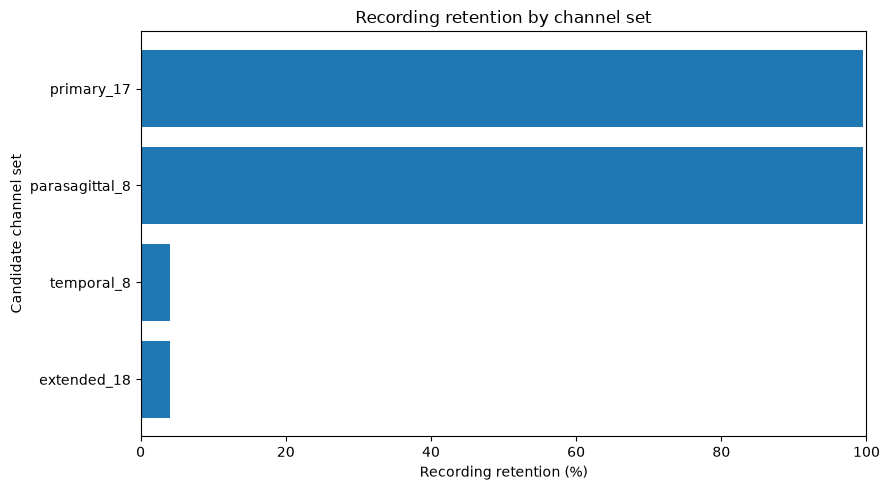

In [5]:
plot_data = summary.sort_values(
    "recording_retention_fraction"
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_data["channel_set_name"],
    plot_data["recording_retention_fraction"] * 100,
)

ax.set_xlabel("Recording retention (%)")
ax.set_ylabel("Candidate channel set")
ax.set_title("Recording retention by channel set")
ax.set_xlim(0, 100)

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "candidate_file_retention.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

# Seizure retention

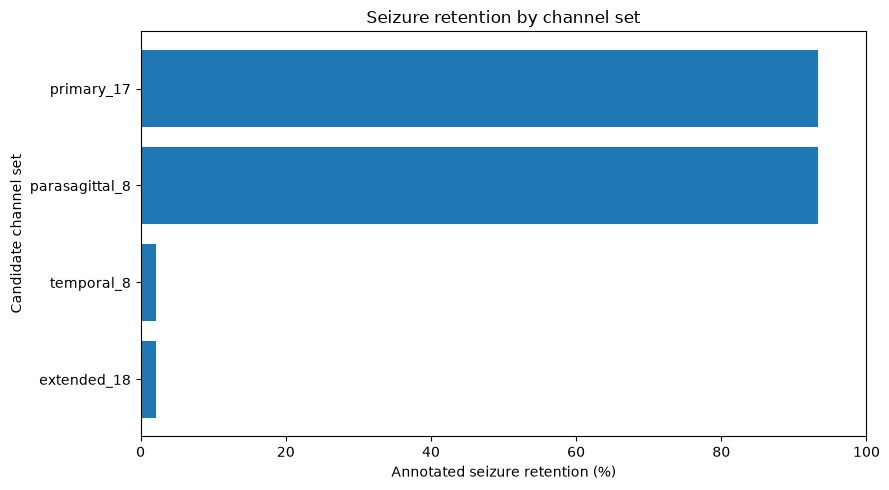

In [6]:
plot_data = summary.sort_values(
    "seizure_retention_fraction"
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_data["channel_set_name"],
    plot_data["seizure_retention_fraction"] * 100,
)

ax.set_xlabel("Annotated seizure retention (%)")
ax.set_ylabel("Candidate channel set")
ax.set_title("Seizure retention by channel set")
ax.set_xlim(0, 100)

fig.tight_layout()
fig.savefig(
    REPORT_DIR / "candidate_seizure_retention.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()